In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
import xml.etree.ElementTree as ET
import time 
import datetime
from matplotlib import cm
import matplotlib
from iminuit import Minuit
from iminuit.cost import ExtendedUnbinnedNLL, ExtendedBinnedNLL
from numba_stats import truncnorm, truncexpon
from scipy.stats import skewnorm
import scipy.stats as Stats



matplotlib.rcParams["font.size"] = 30
matplotlib.rcParams["lines.linewidth"] = 3
matplotlib.rcParams["mathtext.default"] = 'regular'
matplotlib.rcParams['lines.markersize'] = 3

In [2]:
class ChData:
    def __init__(self,ch,E):
        self.ch = int(ch)
        self.E = [E]
        # self.t = [t]
        
    def AddEvent(self,E):
        self.E.append(E)
        # self.t.append(t)
    
        
        
class coincData:
    def __init__(self,channel,Energy):
        self.chList = channel
        self.chData = {}
        for i,ch in enumerate(channel):
            self.chData.update({f'{ch}' : ChData(int(ch),Energy[i])})
        
        # print(self.chData['4'].ch)
        
    def AddEvent(self,channel,Energy):
        
        for i, ch in enumerate(channel):
            self.chData[f'{ch}'].AddEvent(Energy[i])


def readInData(file, scaleFactor = None):
    with open(file) as f: 
        for i in range(3): #skips the first 3 lines of the file. 
            next(f)
            
        date = str(file.parent.parent.parent.parent).split('/')[-1]
        date = date.replace('_','-')
        for i, line in enumerate(f):
            if i == 0: #Look at the third line to get the total number of channels in this coincidence. 
                numChannels = int(line.split("\n")[0].split(": ")[1])
            else:
                
                data = line.split("\n")[0].split(";")
                ch, E, t = [],[],[]
                for j in range(numChannels):
                    ch.append(int(data[6*j+1]))
                    # t.append(float(data[6*j+2])/1e3)
                    if scaleFactor is not None:
                        for s in scaleFactor:
                            if s.ch == int(data[6*j+1]):
                                scaleFac = s.scale[date]
                                break
                            else:
                                pass
                                
                        E.append(float(data[6*j+3])/scaleFac)
                        
                    else:
                        E.append(float(data[6*j+3]))
                if i == 1: #Use the first line to initialize the class objects using the channels. 
                    cData = coincData(ch,E)
                else:
                    cData.AddEvent(ch,E)
                    
    return cData

def ReadInChannelNames(settings):
    ##############################################################################################
    #   Function that reads in the settings.xml file produced by CoMPASS to grab the channel     #
    #   labels and make a dictionary for them. Note that I did use chatGPT to make this function #
    #   As much as it shames me, I had no idea how to read in this file so I cheated a bit.      #
    #   I have gone through the code, and the comments that ChatGPT left and it all makes sense. #
    #   I have also tested it to ensure that it is working properly.                             #
    ##############################################################################################    

    # Parse the XML file into a tree structure
    tree = ET.parse(settings)
    root = tree.getroot()

    # Initialize an empty dictionary to store channel index and label pairs
    channels = {}

    # Iterate over every <channel> element in the file
    for ch in root.iter("channel"):
        # Find the <index> tag within this <channel> element
        index_elem = ch.find("index")
        
        # Find the <values> tag, which contains parameter entries like labels
        values_elem = ch.find("values")
        
        # Continue only if both index and values are found
        if index_elem is not None and values_elem is not None:
            label = None  # Placeholder for the channel label text

            # Search through each <entry> element under <values>
            for entry in values_elem.findall("entry"):
                # Each entry has a <key> and <value>
                key_elem = entry.find("key")
                value_elem = entry.find("value")
                
                # Check if this entry is the label for the channel
                if key_elem is not None and key_elem.text == "SW_PARAMETER_CH_LABEL":
                    # If found, extract the label text (safely)
                    label = value_elem.text.strip() if value_elem is not None else None
                    break  # No need to check further entries for this channel

            # If a label was found, store it in the dictionary with its index
            if label is not None:
                channels[f'Channel {int(index_elem.text)}'] = [label]

    # Print the resulting dictionary: {channel_index: label, ...}
    return channels

def BinHistograms(data, Range, numBins):
    #########################################
    #   Small function to bin histograms    #
    #########################################
    
    binRange = np.linspace(Range[0],Range[1],numBins) #Sets the range to bin over. 
    hist,binedges = np.histogram(data,binRange) #Bins the histogram. 
    
    return hist, binedges


In [41]:
class Summed2DHist:
    def __init__(self,ch):
        self.dates = []
        self.Channels = ch #List of the channels that are being summed (LSC is always along the x-axis. NaI are always along the y-axis)
        self.xInts = np.array([]) #Integrals along the x axis
        self.yInts = np.array([]) #Integrals along the y axis
        
        self.SeparationPoints = []
        self.sumChannels = np.array([])
        
    def addHistData(self,xData,yData, date):

        self.xInts = np.concatenate((self.xInts,xData)) #Adds the latest data to the x and y arrays
        self.yInts = np.concatenate((self.yInts,yData))
        
        
        xData = np.asarray(xData,dtype='float64')
        yData = np.asarray(yData,dtype='float64')
        self.sumChannels = np.concatenate((self.sumChannels,(xData + yData)))
        if date in self.dates:
            self.SeparationPoints[-1] + len(self.xInts)
        else:
            self.dates.append(date)
            self.SeparationPoints.append(len(self.xInts)) #Adds the separation point to note where each day stops. 
        
    
    def plot2DHist(self,axsFlat,savefilepath,scaleData,ind,chPairs):
        
        bins = 100
        
        if scaleData:
            binRangeX = [0,750]
            binRangeY = [0,750]
        else:
            binRangeX = [0,4000]
            binRangeY = [0,4000]
        # fig,ax = plt.subplots(4,2,figsize = (10,10))
        # plt.tight_layout()
        # plt.subplots_adjust(left = 0.05, bottom = 0.05,hspace = 0.2,wspace = 0.2)
        
        # axsFlat = ax.flatten()
        
        

        axsFlat[ind].hist2d(self.xInts,self.yInts, bins = [bins,bins], range = [binRangeX,binRangeY], cmin = 1,rasterized=True,edgecolor='face')
        axsFlat[ind].set_xlabel('LSC Int (ADC)')
        axsFlat[ind].set_ylabel('NaI Int (ADC)')
            
        axsFlat[ind].set_title(chPairs)    
            

        
    def plotSummed1DHist(self,axsFlat,savefilepath,scaleData,ind,chPairs,fitData,plotRange):
        
        bins = 100
        # if scaleData:
        #     binRange = [0,1400]
        # else:
        #     binRange = [0,3000]
        
        binRange = [plotRange[0],2 * plotRange[1]]
        
        
        counts, mplBins, patches = axsFlat[ind].hist(self.sumChannels, bins = bins, range = binRange,histtype = 'step')
        axsFlat[ind].set_xlabel('LSC Int + NaI Int (ADC)')
            
            
        axsFlat[ind].set_ylabel('Counts/bin')
        axsFlat[ind].set_title(chPairs)
        axsFlat[ind].legend(loc = 'best')
        
        if fitData:
            m = self.FitData(axsFlat[ind],binRange,counts,bins)
            # m = self.FitDataExp(axsFlat[ind],binRange,counts,bins)
        
    def FitData(self,ax,xLim,counts,nBins):
        
        bins,step = np.linspace(xLim[0],xLim[1],nBins+1,retstep=True)
        
        C = ExtendedBinnedNLL(counts,bins,SkewPlusGauss_CDF)
        
        #1. nSkew
        #2. muSkew
        #3. sigmaSkew
        #4. skew
        #5. nGauss
        #6. muGauss
        #7. sigmaGauss
        self.nSkew = 0.5*sum(counts)
        self.muSkew = 1000
        self.sigmaSkew = 0.1*self.muSkew
        self.skew = 4
        self.nGauss = 0.5*sum(counts)
        self.muGauss = 5000
        self.sigmaGauss = 0.1*self.muGauss
        
        initFit = [self.nSkew,self.muSkew,self.sigmaSkew,self.skew,self.nGauss,self.muGauss,self.sigmaGauss]
        
        m = Minuit(C,nSkew = initFit[0],muSkew = initFit[1],sigmaSkew = initFit[2],skew = initFit[3], nGauss = initFit[4], muGauss = initFit[5], sigmaGauss= initFit[6])
        m.limits['nSkew', 'muSkew', 'sigmaSkew', 'nGauss', 'muGauss', 'sigmaGauss'] = (0,None)
        m.limits['skew'] = (0,25)
        
        m.migrad()
        m.hesse()
        
        print(r"$\chi$^2 = " + f"{round(m.fval,2)}")
        print(r"dof = " + f"{round(m.ndof,2)}")
        print(r'$chi$^2 / ndof = ' + f"{m.fval/m.ndof}")
        print(m)
        
        xRange = np.linspace(xLim[0], xLim[1], 1000)
        
        skewPlusGauss = step * SkewPlusGauss_PDF(xRange,m.values[0],m.values[1],m.values[2],m.values[3],m.values[4],m.values[5],m.values[6])
        skewFunc = step * SkewPDF(xRange,m.values[0],m.values[1],m.values[2],m.values[3])
        GaussFunc = step * gauss(xRange,m.values[4],m.values[5],m.values[6]) 
        
        ax.plot(xRange,skewPlusGauss,label = 'fit', linewidth = 4)
        ax.plot(xRange,skewFunc, linestyle = 'dashed', color = 'black', alpha = 0.5)
        ax.plot(xRange,GaussFunc, linestyle = 'dashed', color = 'black', alpha = 0.5)
        # ax.plot([],[],' ', label = r"$\chi$^2 = " + f"{round(m.fval,2)}")
        # ax.plot([],[],' ', label = r"dof = " + f"{round(m.ndof,2)}")
        ax.plot([],[],' ', label = r"$\chi$^2/dof = " + f"{round(m.fval/m.ndof,2)}")    
        
        ax.legend(loc = 'best')
        
        
        return m
    
    def FitDataExp(self,ax,xLim,counts,nBins):
        
        bins,step = np.linspace(xLim[0],xLim[1],nBins+1,retstep=True)
        
        C = ExtendedBinnedNLL(counts,bins,ExpSkewPlusGauss_CDF)
        
        #1. nSkew
        #2. muSkew
        #3. sigmaSkew
        #4. skew
        #5. nGauss
        #6. muGauss
        #7. sigmaGauss
        #8. nExp
        #9. muExp 
        #10. tau
        #11. xLim1 
        #12. xLim2
        self.nSkew = 0.5*sum(counts)
        self.muSkew = 1000
        self.sigmaSkew = 0.1*self.muSkew
        self.skew = 4
        self.nGauss = 0.5*sum(counts)
        self.muGauss = 5000
        self.sigmaGauss = 0.1*self.muGauss
        self.nExp = 0.2*sum(counts)
        self.muExp = self.muSkew
        self.tau = 10
        self.xLim1 = xLim[0]
        self.xLim2 = xLim[1]
        
        initFit = [self.nSkew,self.muSkew,self.sigmaSkew,self.skew,self.nGauss,self.muGauss,self.sigmaGauss,self.nExp,self.muExp,self.tau,self.xLim1,self.xLim2]
        
        m = Minuit(C,nSkew = initFit[0],muSkew = initFit[1],sigmaSkew = initFit[2],skew = initFit[3], nGauss = initFit[4], muGauss = initFit[5], sigmaGauss= initFit[6],nExp = initFit[7],muExp = initFit[8],tau = initFit[9],xLim1 = initFit[10],xLim2 = initFit[11])
        m.limits['nSkew', 'muSkew', 'sigmaSkew', 'nGauss', 'muGauss', 'sigmaGauss','nExp','muExp','tau','xLim1','xLim2'] = (0,None)
        m.limits['skew'] = (0,25)
        
        m.migrad()
        m.hesse()
        
        print(r"$\chi$^2 = " + f"{round(m.fval,2)}")
        print(r"dof = " + f"{round(m.ndof,2)}")
        print(r'$chi$^2 / ndof = ' + f"{m.fval/m.ndof}")
        print(m)
        
        xRange = np.linspace(xLim[0], xLim[1], 1000)
        
        ExpskewPlusGauss = step * ExpSkewPlusGauss_PDF(xRange,m.values[0],m.values[1],m.values[2],m.values[3],m.values[4],m.values[5],m.values[6],m.values[7],m.values[8],m.values[9],m.values[10],m.values[11])
        skewFunc = step * SkewPDF(xRange,m.values[0],m.values[1],m.values[2],m.values[3])
        GaussFunc = step * gauss(xRange,m.values[4],m.values[5],m.values[6]) 
        exponFunc = step * expFunc(xRange,m.values[7],m.values[8],m.values[9],m.values[10],m.values[11])
        
        ax.plot(xRange,ExpskewPlusGauss,label = 'fit', linewidth = 4)
        ax.plot(xRange,skewFunc, linestyle = 'dashed', color = 'red', alpha = 0.5)
        ax.plot(xRange,GaussFunc, linestyle = 'dashed', color = 'red', alpha = 0.5)
        ax.plot(xRange,exponFunc, linestyle = 'dashed', color = 'red', alpha = 0.5)
        # ax.plot([],[],' ', label = r"$\chi$^2 = " + f"{round(m.fval,2)}")
        # ax.plot([],[],' ', label = r"dof = " + f"{round(m.ndof,2)}")
        ax.plot([],[],' ', label = r"Exp $\chi$^2/dof = " + f"{round(m.fval/m.ndof,2)}")    
        
        ax.legend(loc = 'best')
        
        
        return m
        

    def plotOverlayedHist(self,savefilepath,scaleData):
        
        bins = 100
        if scaleData:
            binRange = [0,1400]
        else:
            binRange = [0,4000]
        
        fig,ax = plt.subplots(1,1,figsize = (10,10))
        
        plt.tight_layout()
        plt.subplots_adjust(left = 0.1, bottom = 0.08)
        cmap = cm.viridis
        colours = [cmap(i/(len(self.SeparationPoints))) for i in range(len(self.SeparationPoints))]
        
        for i in range(len(self.SeparationPoints)):
            counts,binsedges = BinHistograms(self.sumChannels[0:self.SeparationPoints[i]],binRange,bins)
            ax.hist(binsedges[:-1],bins = binsedges,weights = counts/max(counts), histtype = 'step', color = colours[i])
            # ax.hist(self.sumChannels[0:self.SeparationPoints[i]], bins = bins, range = binRange, histtype='step', color=colours[i])
        if scaleData:
            ax.set_xlabel('LSC Int + NaI Int (keV)')
        else:
            ax.set_xlabel('LSC Int + NaI Int (ADC)')
        ax.set_ylabel('Counts/bin')
        
        sm = cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=1, vmax=len(self.SeparationPoints)))
        cbar = fig.colorbar(sm, ax=ax)
        cbar.set_label("Day", labelpad=25)
        
        savepath = savefilepath / 'Summed_Histograms'
        savepath.mkdir(parents=True,exist_ok=True)
        
        plt.show()

        


def SkewPlusGauss_CDF(x,nSkew,muSkew,sigmaSkew,skew,nGauss,muGauss,sigmaGauss):
    skew = nSkew*skewnorm.cdf(x,a = skew, loc = muSkew, scale = sigmaSkew)
    Gauss = nGauss*Stats.norm.cdf(x, loc = muGauss, scale = sigmaGauss)
    
    return skew + Gauss

def SkewPlusGauss_PDF(x,nSkew,muSkew,sigmaSkew,skew,nGauss,muGauss,sigmaGauss):
    skew = nSkew*skewnorm.pdf(x,a = skew, loc = muSkew, scale = sigmaSkew)
    Gauss = nGauss*Stats.norm.pdf(x, loc = muGauss, scale = sigmaGauss)
    
    return skew + Gauss

def SkewPDF(x,nSkew,muSkew,sigmaSkew,skew):
    return nSkew*skewnorm.pdf(x,a = skew, loc = muSkew, scale = sigmaSkew)  

def gauss(x,nGauss,muGauss,sigmaGauss):
    return nGauss*Stats.norm.pdf(x, loc = muGauss, scale = sigmaGauss)

def ExpSkewPlusGauss_CDF(x,nSkew,muSkew,sigmaSkew,skew,nGauss,muGauss,sigmaGauss,nExp,muExp,tau,xLim1,xLim2):
    skew = nSkew*skewnorm.cdf(x,a = skew, loc = muSkew, scale = sigmaSkew)
    Gauss = nGauss*Stats.norm.cdf(x, loc = muGauss, scale = sigmaGauss)
    Exp = nExp * truncexpon.cdf(x, xLim1, xLim2, loc = muExp, scale = tau)
    
    return skew + Gauss + Exp

def ExpSkewPlusGauss_PDF(x,nSkew,muSkew,sigmaSkew,skew,nGauss,muGauss,sigmaGauss,nExp,muExp,tau,xLim1,xLim2):
    skew = nSkew*skewnorm.pdf(x,a = skew, loc = muSkew, scale = sigmaSkew)
    Gauss = nGauss*Stats.norm.pdf(x, loc = muGauss, scale = sigmaGauss)
    Exp = nExp * truncexpon.pdf(x, xLim1, xLim2, loc = muExp, scale = tau)
    
    return skew + Gauss + Exp

def expFunc(x, nExp, muExp, tau, xLim1,xLim2):
    return nExp * truncexpon.pdf(x, xLim1, xLim2, loc = muExp, scale = tau)

In [44]:
# rootfilePath = Path('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/2026_07_08/2026_07_08_Daily_LSC_calibration_bck_coinc/RAW/coinc_sorted_500ns/')
# rootfilePath = Path('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/2026_06_24/2026_06_24_Daily_LSC_calibration_Cs137_coinc_new_settings_lower_thresh/RAW/coinc_sorted_500ns/')

# rootfilePath = Path('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/2026_07_09/2026_07_09_Daily_LSC_calibration_bck_coinc_Lower_LSC_HV/RAW/coinc_sorted_500ns/')

rootfilePath = Path('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/2026_07_10/2026_07_10_Daily_LSC_calibration_bCs137_coinc_1500_LSC_HV/RAW/coinc_sorted_500ns/')

LSCChannels = [0,1]
NaIChannels = [2,3,4,5]

plotRange = [0,4000]


# rootfilePath = Path('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/2026_06_12/2026_06_12_Daily_LSC_calibration_Cs137_coinc/RAW/coinc_sorted/')
# LSCChannels = [4,5]
# NaIChannels = [8,10,12,14]
# plotRange = [0,2000]

pattern = re.compile(rf'_coinc_{LSCChannels[0]}_{LSCChannels[1]}_({NaIChannels[0]}|{NaIChannels[1]}|{NaIChannels[2]}|{NaIChannels[3]}).txt$')

coincFiles = sorted([
    f for f in rootfilePath.glob(f'**/*_coinc_{LSCChannels[0]}_{LSCChannels[1]}_*.txt')
    if pattern.search(f.name)
])
histogramData = []
for i in LSCChannels:
    for j in NaIChannels:
        histogramData.append(Summed2DHist([i,j]))

readInStartTime = time.time()
print('Reading in histogram data:')

for i,filePath in enumerate(coincFiles):
    date = filePath.parent.parent.parent.parent.stem
    settingsFilePath = filePath.parent.parent.parent / 'settings.xml'
    savefilepath = Path('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/stability_figures/')
    if i == 0:
        Detectors = ReadInChannelNames(settingsFilePath)
    cData = readInData(filePath)
    
    chPairs = [[cData.chList[0],cData.chList[2]], [cData.chList[1],cData.chList[2]]] #Makes a 2D array with the two channel pairs for the summed histogram data. 
    print(cData.chList)
    
    for j,hist in enumerate(histogramData):
            if hist.Channels == chPairs[0]:
                hist.addHistData(cData.chData[str(chPairs[0][0])].E,cData.chData[str(chPairs[0][1])].E,date)
            elif hist.Channels == chPairs[1]:
                hist.addHistData(cData.chData[str(chPairs[1][0])].E,cData.chData[str(chPairs[1][1])].E,date)

Reading in histogram data:
[0, 1, 2]
[0, 1, 3]
[0, 1, 4]
[0, 1, 5]


Plotting Histogram from channels: [0, 2]
Plotting Histogram from channels: [0, 3]
Plotting Histogram from channels: [0, 4]
Plotting Histogram from channels: [0, 5]
Plotting Histogram from channels: [1, 2]
Plotting Histogram from channels: [1, 3]
Plotting Histogram from channels: [1, 4]
Plotting Histogram from channels: [1, 5]


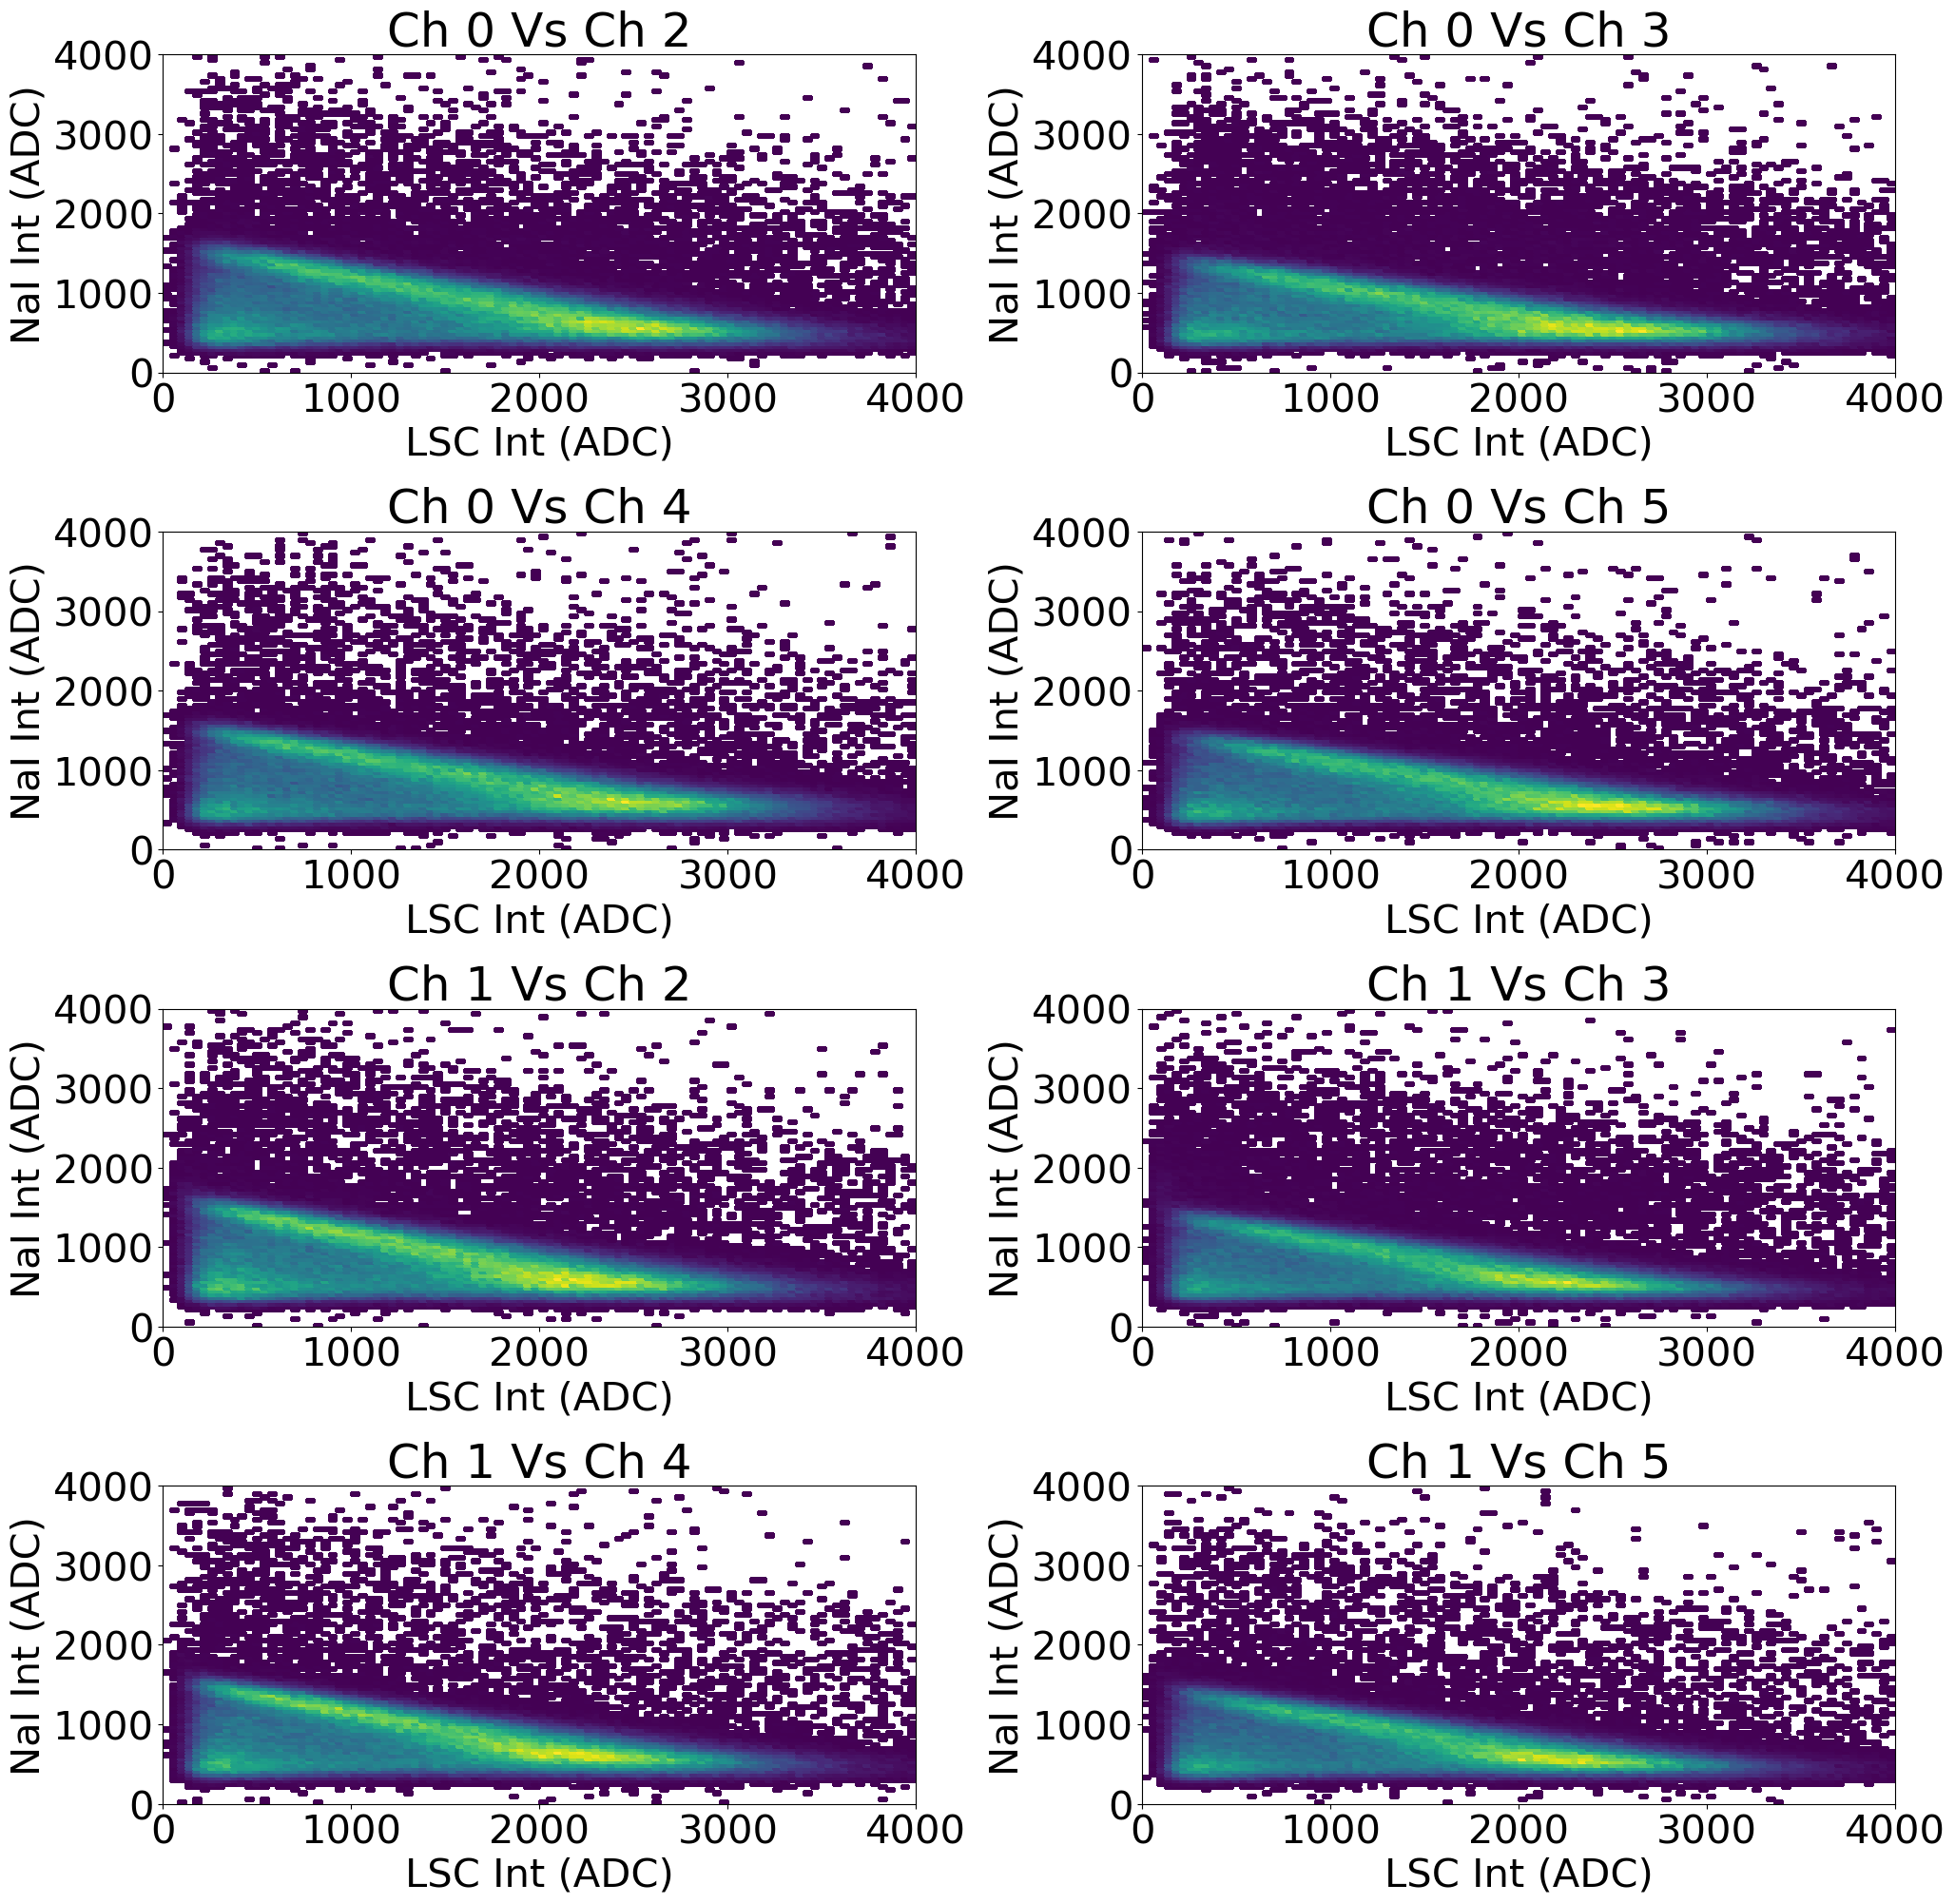

Plotting Summed Channel data from channels: [0, 2]


/tmp/ipykernel_686491/3307563684.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axsFlat[ind].legend(loc = 'best')


$\chi$^2 = 1380.65
dof = 93.0
$chi$^2 / ndof = 14.845673238220856
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1381 (χ²/ndof = 14.8)      │             Nfcn = 1198              │
│ EDM = 2.54 (Goal: 0.0002)        │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   ABOVE EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────────┬────

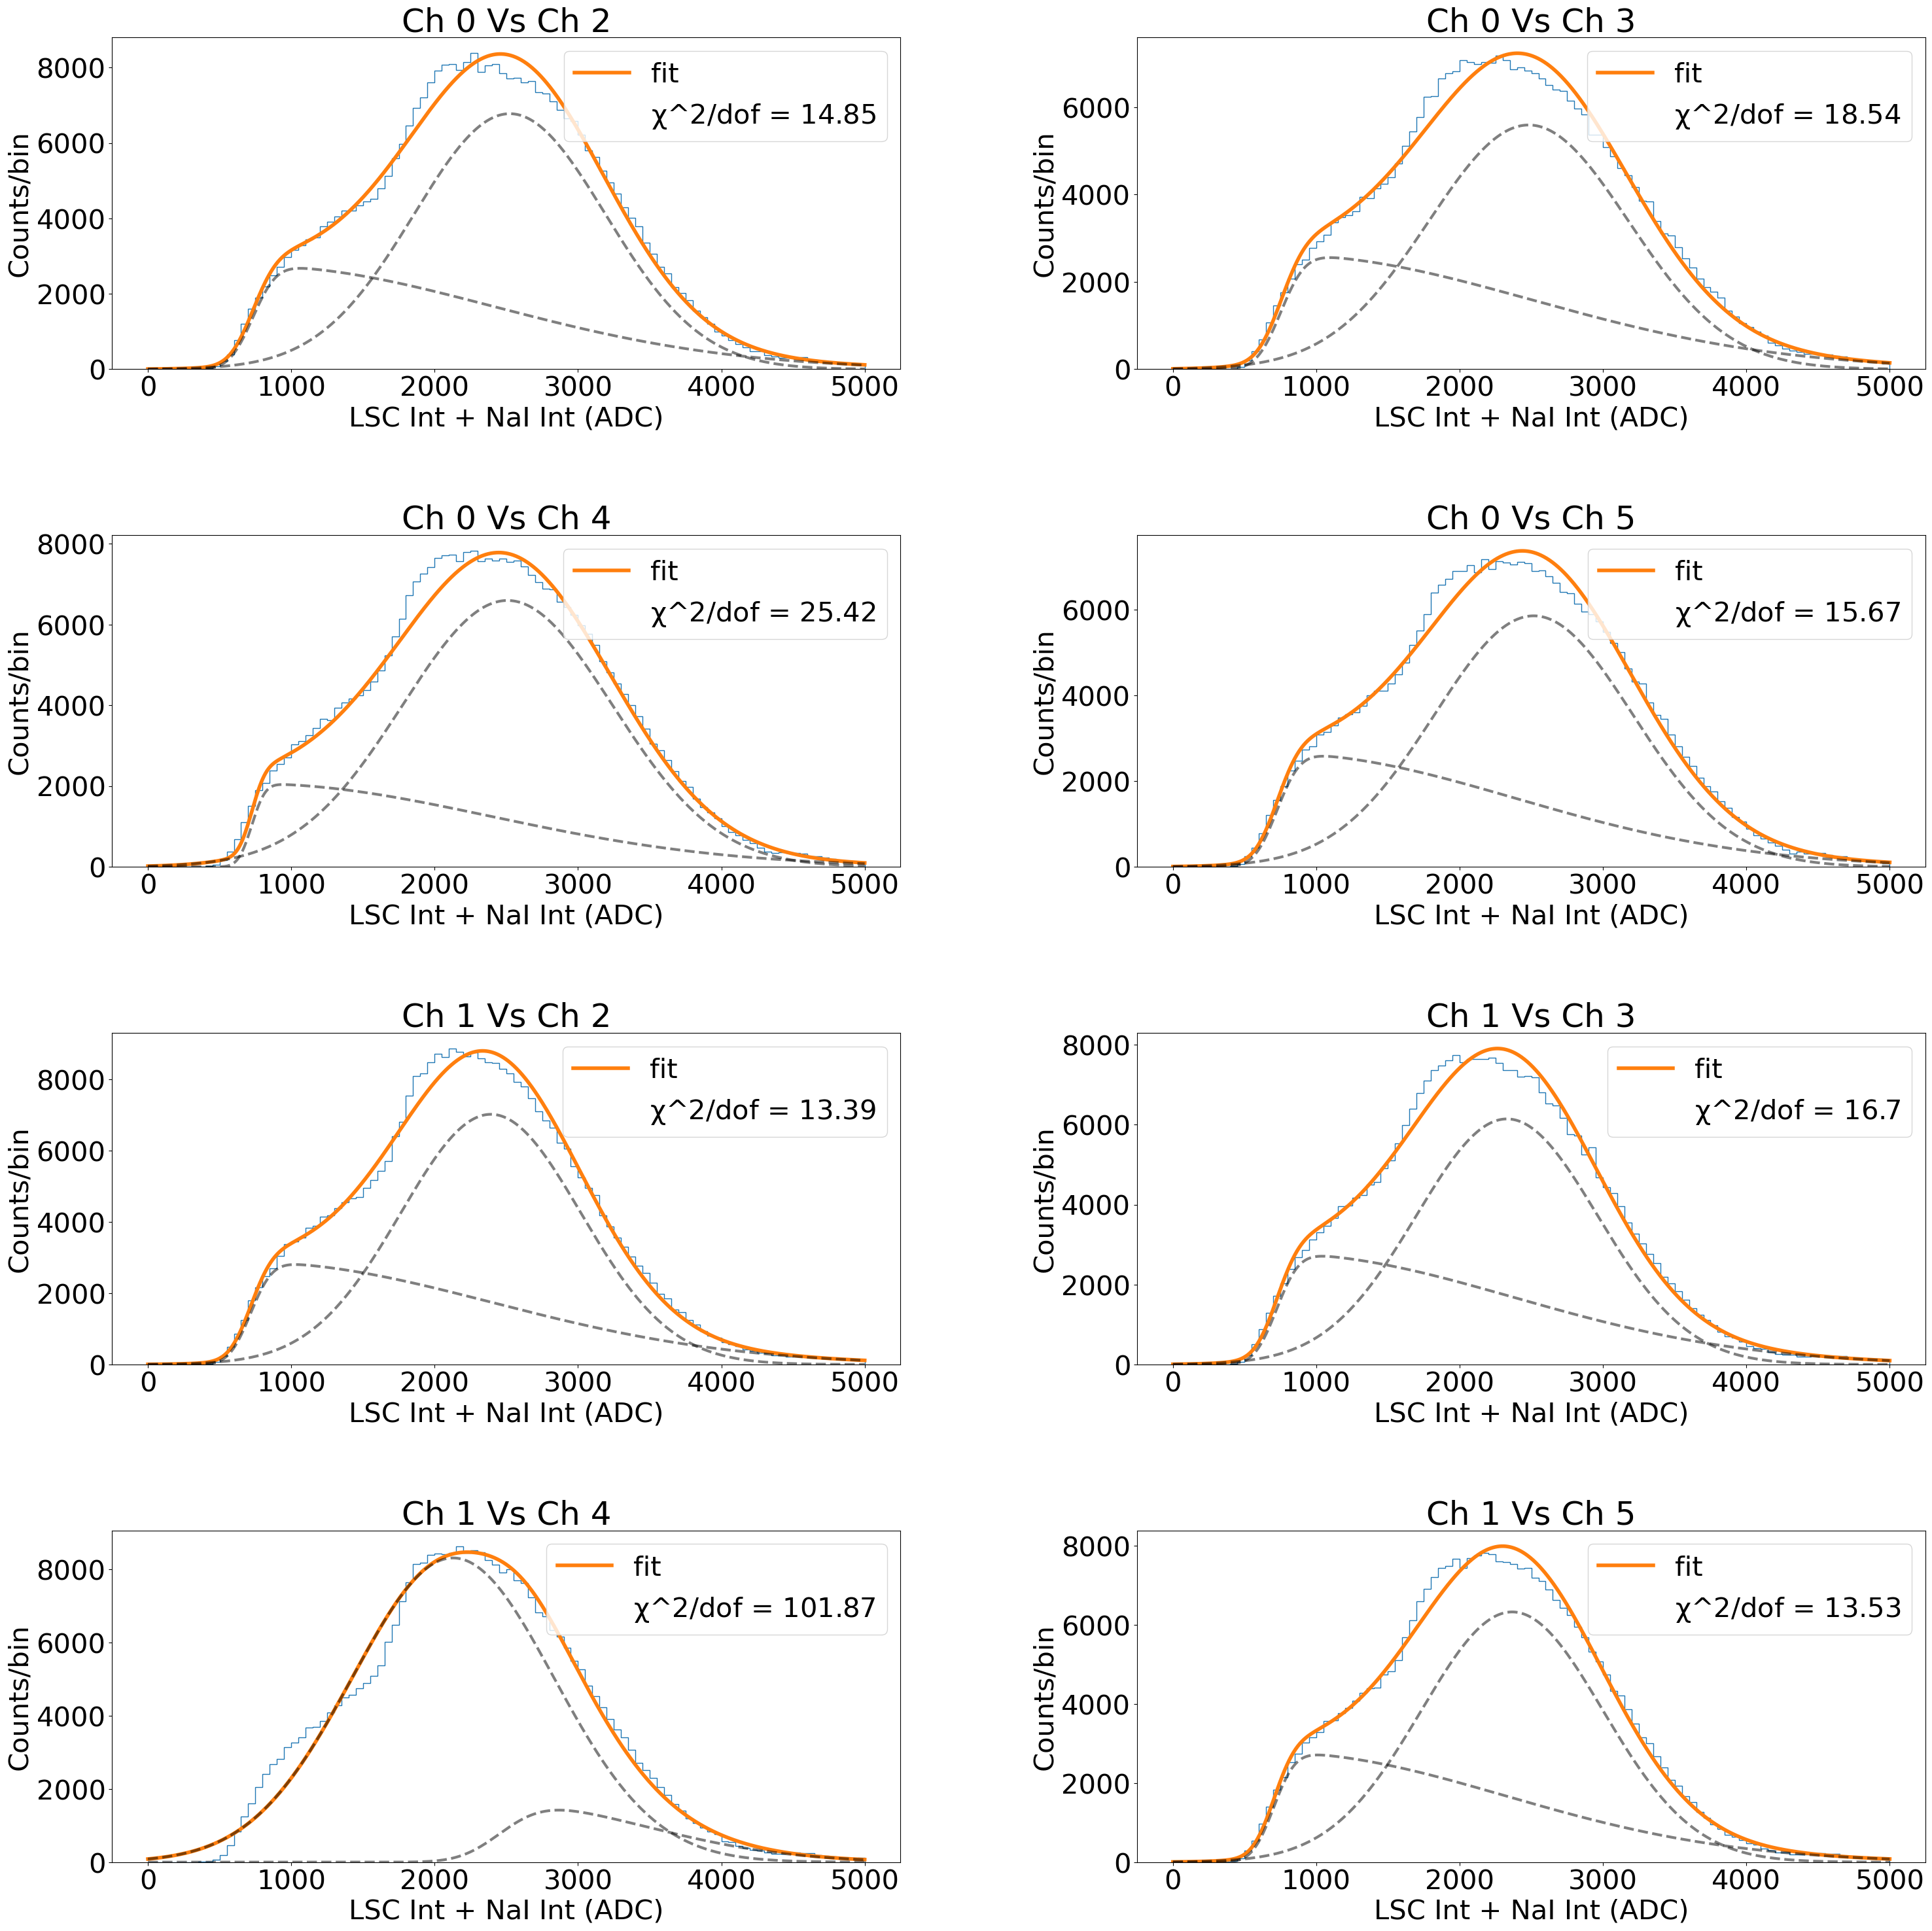

In [47]:

fig,ax = plt.subplots(4,2,figsize = (20,20))
plt.tight_layout()
plt.subplots_adjust(left = 0.05, bottom = 0.05,hspace = 0.5,wspace = 0.3)

axsFlat = ax.flatten()
for i,hist in enumerate(histogramData):
    chPairs = f'Ch {hist.Channels[0]} Vs Ch {hist.Channels[1]}'
    print(f'Plotting Histogram from channels: {hist.Channels}')
    
    hist.plot2DHist(axsFlat,savefilepath,False,i,chPairs)
plt.show()
    
    

fitData = True
fig,ax = plt.subplots(4,2,figsize = (30,30))
plt.tight_layout()
plt.subplots_adjust(left = 0.05, bottom = 0.05,hspace = 0.5,wspace = 0.3)

axsFlat = ax.flatten()
for i,hist in enumerate(histogramData):
    chPairs = f'Ch {hist.Channels[0]} Vs Ch {hist.Channels[1]}'
    print(f"Plotting Summed Channel data from channels: {hist.Channels}")
    hist.plotSummed1DHist(axsFlat,savefilepath,False,i,chPairs,fitData,[0,2500])
    
plt.show()

In [32]:
class Summed2DHist:
    def __init__(self,ch):
        self.dates = []
        self.Channels = ch #List of the channels that are being summed (LSC is always along the x-axis. NaI are always along the y-axis)
        self.xInts = np.array([]) #Integrals along the x axis
        self.yInts = np.array([]) #Integrals along the y axis
        
        self.SeparationPoints = []
        self.sumChannels = np.array([])
        
    def addHistData(self,xData,yData, date):

        self.xInts = np.concatenate((self.xInts,xData)) #Adds the latest data to the x and y arrays
        self.yInts = np.concatenate((self.yInts,yData))
        
        
        xData = np.asarray(xData,dtype='float64')
        yData = np.asarray(yData,dtype='float64')
        self.sumChannels = np.concatenate((self.sumChannels,(xData + yData)))
        if date in self.dates:
            self.SeparationPoints[-1] + len(self.xInts)
        else:
            self.dates.append(date)
            self.SeparationPoints.append(len(self.xInts)) #Adds the separation point to note where each day stops. 
        
    
    def plot2DHist(self,axsFlat,savefilepath,scaleData,ind,chPairs):
        
        bins = 100
        
        if scaleData:
            binRangeX = [0,750]
            binRangeY = [0,750]
        else:
            binRangeX = [0,4000]
            binRangeY = [0,4000]
        # fig,ax = plt.subplots(4,2,figsize = (10,10))
        # plt.tight_layout()
        # plt.subplots_adjust(left = 0.05, bottom = 0.05,hspace = 0.2,wspace = 0.2)
        
        # axsFlat = ax.flatten()
        
        

        axsFlat[ind].hist2d(self.xInts,self.yInts, bins = [bins,bins], range = [binRangeX,binRangeY], cmin = 1,rasterized=True,edgecolor='face')
        axsFlat[ind].set_xlabel('LSC Int (ADC)')
        axsFlat[ind].set_ylabel('NaI Int (ADC)')
            
        axsFlat[ind].set_title(chPairs)    
            

        
    def plotSummed1DHist(self,axsFlat,savefilepath,scaleData,ind,chPairs,fitData,plotRange):
        
        bins = 100
        # if scaleData:
        #     binRange = [0,1400]
        # else:
        #     binRange = [0,3000]
        
        binRange = [plotRange[0],2 * plotRange[1]]
        
        
        counts, mplBins, patches = axsFlat[ind].hist(self.sumChannels, bins = bins, range = binRange,histtype = 'step')
        axsFlat[ind].set_xlabel('LSC Int + NaI Int (ADC)')
            
            
        axsFlat[ind].set_ylabel('Counts/bin')
        axsFlat[ind].set_title(chPairs)
        axsFlat[ind].legend(loc = 'best')
        
        if fitData:
            # m = self.FitData(axsFlat[ind],binRange,counts,bins)
            m = self.FitDataGauss(axsFlat[ind],binRange,counts,bins)
            # m = self.FitDataExp(axsFlat[ind],binRange,counts,bins)
        
    def FitData(self,ax,xLim,counts,nBins):
        
        bins,step = np.linspace(xLim[0],xLim[1],nBins+1,retstep=True)
        
        C = ExtendedBinnedNLL(counts,bins,SkewPlusGauss_CDF)
        
        #1. nSkew
        #2. muSkew
        #3. sigmaSkew
        #4. skew
        #5. nGauss
        #6. muGauss
        #7. sigmaGauss
        self.nSkew = 0.5*sum(counts)
        self.muSkew = 1000
        self.sigmaSkew = 0.1*self.muSkew
        self.skew = 4
        self.nGauss = 0.5*sum(counts)
        self.muGauss = 5000
        self.sigmaGauss = 0.1*self.muGauss
        
        initFit = [self.nSkew,self.muSkew,self.sigmaSkew,self.skew,self.nGauss,self.muGauss,self.sigmaGauss]
        
        m = Minuit(C,nSkew = initFit[0],muSkew = initFit[1],sigmaSkew = initFit[2],skew = initFit[3], nGauss = initFit[4], muGauss = initFit[5], sigmaGauss= initFit[6])
        m.limits['nSkew', 'muSkew', 'sigmaSkew', 'nGauss', 'muGauss', 'sigmaGauss'] = (0,None)
        m.limits['skew'] = (0,25)
        
        m.migrad()
        m.hesse()
        
        print(r"$\chi$^2 = " + f"{round(m.fval,2)}")
        print(r"dof = " + f"{round(m.ndof,2)}")
        print(r'$chi$^2 / ndof = ' + f"{m.fval/m.ndof}")
        print(m)
        
        xRange = np.linspace(xLim[0], xLim[1], 1000)
        
        skewPlusGauss = step * SkewPlusGauss_PDF(xRange,m.values[0],m.values[1],m.values[2],m.values[3],m.values[4],m.values[5],m.values[6])
        skewFunc = step * SkewPDF(xRange,m.values[0],m.values[1],m.values[2],m.values[3])
        GaussFunc = step * gauss(xRange,m.values[4],m.values[5],m.values[6]) 
        
        ax.plot(xRange,skewPlusGauss,label = 'fit', linewidth = 4)
        ax.plot(xRange,skewFunc, linestyle = 'dashed', color = 'black', alpha = 0.5)
        ax.plot(xRange,GaussFunc, linestyle = 'dashed', color = 'black', alpha = 0.5)
        # ax.plot([],[],' ', label = r"$\chi$^2 = " + f"{round(m.fval,2)}")
        # ax.plot([],[],' ', label = r"dof = " + f"{round(m.ndof,2)}")
        ax.plot([],[],' ', label = r"$\chi$^2/dof = " + f"{round(m.fval/m.ndof,2)}")    
        
        ax.legend(loc = 'best')
        
        
        return m
    
    def FitDataGauss(self,ax,xLim,counts,nBins):
        
        self.nGauss = 0.5*sum(counts)
        self.muGauss = 1200
        self.sigmaGauss = 0.1*self.muGauss
        self.a = self.muGauss - 500
        self.b = self.muGauss + 500
        
        bins,step = np.linspace(self.a,self.b,nBins+1,retstep=True)
        
        counts, mplbins,patches = ax.hist(self.sumChannels,bins = bins,histtype = 'step', color = 'black')
        C = ExtendedBinnedNLL(counts,bins,TruncgaussCDF)
        
        #1. nGauss
        #2. muGauss
        #3. sigmaGauss
        #4. xLim1
        #5. xLim2

        
                
        initFit = [self.nGauss,self.muGauss,self.sigmaGauss,self.a,self.b]
        
        m = Minuit(C,nGauss = initFit[0],muGauss = initFit[1],sigmaGauss = initFit[2],xLim1 = initFit[3],xLim2 = initFit[4])
        m.limits['nGauss', 'muGauss', 'sigmaGauss','xLim1','xLim2'] = (0,None)

        
        m.migrad()
        m.hesse()
        
        print(r"$\chi$^2 = " + f"{round(m.fval,2)}")
        print(r"dof = " + f"{round(m.ndof,2)}")
        print(r'$chi$^2 / ndof = ' + f"{m.fval/m.ndof}")
        print(m)
        
        xRange = np.linspace(xLim[0], xLim[1], 1000)
        
        # skewPlusGauss = step * SkewPlusGauss_PDF(xRange,m.values[0],m.values[1],m.values[2],m.values[3],m.values[4],m.values[5],m.values[6])
        # skewFunc = step * SkewPDF(xRange,m.values[0],m.values[1],m.values[2],m.values[3])
        GaussFunc = step * TruncgaussPDF(xRange,m.values[0],m.values[1],m.values[2],m.values[3],m.values[4]) 
        initFunc = step * TruncgaussPDF(xRange,initFit[0],initFit[1],initFit[2],initFit[3],initFit[4])
        
        # ax.plot(xRange,skewPlusGauss,label = 'fit', linewidth = 4)
        # ax.plot(xRange,skewFunc, linestyle = 'dashed', color = 'black', alpha = 0.5)
        ax.plot(xRange,GaussFunc, linestyle = 'dashed', color = 'black', alpha = 0.5)
        ax.plot(xRange,initFunc, linestyle = 'dashed', color = 'red', alpha = 0.5)
        # ax.plot([],[],' ', label = r"$\chi$^2 = " + f"{round(m.fval,2)}")
        # ax.plot([],[],' ', label = r"dof = " + f"{round(m.ndof,2)}")
        ax.plot([],[],' ', label = r"$\chi$^2/dof = " + f"{round(m.fval/m.ndof,2)}")    
        
        ax.legend(loc = 'best')
        
        
        return m
    
    def FitDataExp(self,ax,xLim,counts,nBins):
        
        bins,step = np.linspace(xLim[0],xLim[1],nBins+1,retstep=True)
        
        C = ExtendedBinnedNLL(counts,bins,ExpSkewPlusGauss_CDF)
        
        #1. nSkew
        #2. muSkew
        #3. sigmaSkew
        #4. skew
        #5. nGauss
        #6. muGauss
        #7. sigmaGauss
        #8. nExp
        #9. muExp 
        #10. tau
        #11. xLim1 
        #12. xLim2
        self.nSkew = 0.5*sum(counts)
        self.muSkew = 1000
        self.sigmaSkew = 0.1*self.muSkew
        self.skew = 4
        self.nGauss = 0.5*sum(counts)
        self.muGauss = 5000
        self.sigmaGauss = 0.1*self.muGauss
        self.nExp = 0.2*sum(counts)
        self.muExp = self.muSkew
        self.tau = 10
        self.xLim1 = xLim[0]
        self.xLim2 = xLim[1]
        
        initFit = [self.nSkew,self.muSkew,self.sigmaSkew,self.skew,self.nGauss,self.muGauss,self.sigmaGauss,self.nExp,self.muExp,self.tau,self.xLim1,self.xLim2]
        
        m = Minuit(C,nSkew = initFit[0],muSkew = initFit[1],sigmaSkew = initFit[2],skew = initFit[3], nGauss = initFit[4], muGauss = initFit[5], sigmaGauss= initFit[6],nExp = initFit[7],muExp = initFit[8],tau = initFit[9],xLim1 = initFit[10],xLim2 = initFit[11])
        m.limits['nSkew', 'muSkew', 'sigmaSkew', 'nGauss', 'muGauss', 'sigmaGauss','nExp','muExp','tau','xLim1','xLim2'] = (0,None)
        m.limits['skew'] = (0,25)
        
        m.migrad()
        m.hesse()
        
        print(r"$\chi$^2 = " + f"{round(m.fval,2)}")
        print(r"dof = " + f"{round(m.ndof,2)}")
        print(r'$chi$^2 / ndof = ' + f"{m.fval/m.ndof}")
        print(m)
        
        xRange = np.linspace(xLim[0], xLim[1], 1000)
        
        ExpskewPlusGauss = step * ExpSkewPlusGauss_PDF(xRange,m.values[0],m.values[1],m.values[2],m.values[3],m.values[4],m.values[5],m.values[6],m.values[7],m.values[8],m.values[9],m.values[10],m.values[11])
        skewFunc = step * SkewPDF(xRange,m.values[0],m.values[1],m.values[2],m.values[3])
        GaussFunc = step * gauss(xRange,m.values[4],m.values[5],m.values[6]) 
        exponFunc = step * expFunc(xRange,m.values[7],m.values[8],m.values[9],m.values[10],m.values[11])
        
        ax.plot(xRange,ExpskewPlusGauss,label = 'fit', linewidth = 4)
        ax.plot(xRange,skewFunc, linestyle = 'dashed', color = 'red', alpha = 0.5)
        ax.plot(xRange,GaussFunc, linestyle = 'dashed', color = 'red', alpha = 0.5)
        ax.plot(xRange,exponFunc, linestyle = 'dashed', color = 'red', alpha = 0.5)
        # ax.plot([],[],' ', label = r"$\chi$^2 = " + f"{round(m.fval,2)}")
        # ax.plot([],[],' ', label = r"dof = " + f"{round(m.ndof,2)}")
        ax.plot([],[],' ', label = r"Exp $\chi$^2/dof = " + f"{round(m.fval/m.ndof,2)}")    
        ax.legend(loc = 'best')
        
        
        return m
        

    def plotOverlayedHist(self,savefilepath,scaleData):
        
        bins = 100
        if scaleData:
            binRange = [0,1400]
        else:
            binRange = [0,4000]
        
        fig,ax = plt.subplots(1,1,figsize = (10,10))
        
        plt.tight_layout()
        plt.subplots_adjust(left = 0.1, bottom = 0.08)
        cmap = cm.viridis
        colours = [cmap(i/(len(self.SeparationPoints))) for i in range(len(self.SeparationPoints))]
        
        for i in range(len(self.SeparationPoints)):
            counts,binsedges = BinHistograms(self.sumChannels[0:self.SeparationPoints[i]],binRange,bins)
            ax.hist(binsedges[:-1],bins = binsedges,weights = counts/max(counts), histtype = 'step', color = colours[i])
            # ax.hist(self.sumChannels[0:self.SeparationPoints[i]], bins = bins, range = binRange, histtype='step', color=colours[i])
        if scaleData:
            ax.set_xlabel('LSC Int + NaI Int (keV)')
        else:
            ax.set_xlabel('LSC Int + NaI Int (ADC)')
        ax.set_ylabel('Counts/bin')
        
        sm = cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=1, vmax=len(self.SeparationPoints)))
        cbar = fig.colorbar(sm, ax=ax)
        cbar.set_label("Day", labelpad=25)
        
        savepath = savefilepath / 'Summed_Histograms'
        savepath.mkdir(parents=True,exist_ok=True)
        
        plt.show()

        


def SkewPlusGauss_CDF(x,nSkew,muSkew,sigmaSkew,skew,nGauss,muGauss,sigmaGauss):
    skew = nSkew*skewnorm.cdf(x,a = skew, loc = muSkew, scale = sigmaSkew)
    Gauss = nGauss*Stats.norm.cdf(x, loc = muGauss, scale = sigmaGauss)
    
    return skew + Gauss

def SkewPlusGauss_PDF(x,nSkew,muSkew,sigmaSkew,skew,nGauss,muGauss,sigmaGauss):
    skew = nSkew*skewnorm.pdf(x,a = skew, loc = muSkew, scale = sigmaSkew)
    Gauss = nGauss*Stats.norm.pdf(x, loc = muGauss, scale = sigmaGauss)
    
    return skew + Gauss

def SkewPDF(x,nSkew,muSkew,sigmaSkew,skew):
    return nSkew*skewnorm.pdf(x,a = skew, loc = muSkew, scale = sigmaSkew)  

def gauss(x,nGauss,muGauss,sigmaGauss):
    return nGauss*Stats.norm.pdf(x, loc = muGauss, scale = sigmaGauss)

def TruncgaussCDF(x,nGauss,muGauss,sigmaGauss,xLim1,xLim2):
    return nGauss*Stats.truncnorm.cdf(x,xLim1,xLim2, loc = muGauss, scale = sigmaGauss)

def TruncgaussPDF(x,nGauss,muGauss,sigmaGauss,xLim1,xLim2):
    return nGauss*Stats.truncnorm.pdf(x,xLim1,xLim2, loc = muGauss, scale = sigmaGauss)

def ExpSkewPlusGauss_CDF(x,nSkew,muSkew,sigmaSkew,skew,nGauss,muGauss,sigmaGauss,nExp,muExp,tau,xLim1,xLim2):
    skew = nSkew*skewnorm.cdf(x,a = skew, loc = muSkew, scale = sigmaSkew)
    Gauss = nGauss*Stats.norm.cdf(x, loc = muGauss, scale = sigmaGauss)
    Exp = nExp * truncexpon.cdf(x, xLim1, xLim2, loc = muExp, scale = tau)
    
    return skew + Gauss + Exp

def ExpSkewPlusGauss_PDF(x,nSkew,muSkew,sigmaSkew,skew,nGauss,muGauss,sigmaGauss,nExp,muExp,tau,xLim1,xLim2):
    skew = nSkew*skewnorm.pdf(x,a = skew, loc = muSkew, scale = sigmaSkew)
    Gauss = nGauss*Stats.norm.pdf(x, loc = muGauss, scale = sigmaGauss)
    Exp = nExp * truncexpon.pdf(x, xLim1, xLim2, loc = muExp, scale = tau)
    
    return skew + Gauss + Exp

def expFunc(x, nExp, muExp, tau, xLim1,xLim2):
    return nExp * truncexpon.pdf(x, xLim1, xLim2, loc = muExp, scale = tau)

In [25]:
rootfilePath = Path('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/2026_06_17/2026_06_17_Daily_LSC_calibration_Cs137_coinc/RAW/coinc_sorted_500ns/')
# rootfilePath = Path('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/2026_06_17/2026_06_17_Daily_LSC_calibration_bck_no_coinc_2/RAW/coinc_sorted_500ns')
LSCChannels = [4,5]
NaIChannels = [8,10,12,14]
plotRange = [0,1500]

pattern = re.compile(rf'_coinc_{LSCChannels[0]}_{LSCChannels[1]}_({NaIChannels[0]}|{NaIChannels[1]}|{NaIChannels[2]}|{NaIChannels[3]}).txt$')

coincFiles = sorted([
    f for f in rootfilePath.glob(f'**/*_coinc_{LSCChannels[0]}_{LSCChannels[1]}_*.txt')
    if pattern.search(f.name)
])
histogramData = []
for i in LSCChannels:
    for j in NaIChannels:
        histogramData.append(Summed2DHist([i,j]))

readInStartTime = time.time()
print('Reading in histogram data:')

for i,filePath in enumerate(coincFiles):
    date = filePath.parent.parent.parent.parent.stem
    settingsFilePath = filePath.parent.parent.parent / 'settings.xml'
    savefilepath = Path('/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/stability_figures/')
    if i == 0:
        Detectors = ReadInChannelNames(settingsFilePath)
    cData = readInData(filePath)
    
    chPairs = [[cData.chList[0],cData.chList[2]], [cData.chList[1],cData.chList[2]]] #Makes a 2D array with the two channel pairs for the summed histogram data. 
    print(cData.chList)
    
    for j,hist in enumerate(histogramData):
            if hist.Channels == chPairs[0]:
                hist.addHistData(cData.chData[str(chPairs[0][0])].E,cData.chData[str(chPairs[0][1])].E,date)
            elif hist.Channels == chPairs[1]:
                hist.addHistData(cData.chData[str(chPairs[1][0])].E,cData.chData[str(chPairs[1][1])].E,date)

Reading in histogram data:
[4, 5, 10]
[4, 5, 12]
[4, 5, 14]
[4, 5, 8]


Plotting Histogram from channels: [4, 8]
Plotting Histogram from channels: [4, 10]
Plotting Histogram from channels: [4, 12]
Plotting Histogram from channels: [4, 14]
Plotting Histogram from channels: [5, 8]
Plotting Histogram from channels: [5, 10]
Plotting Histogram from channels: [5, 12]
Plotting Histogram from channels: [5, 14]


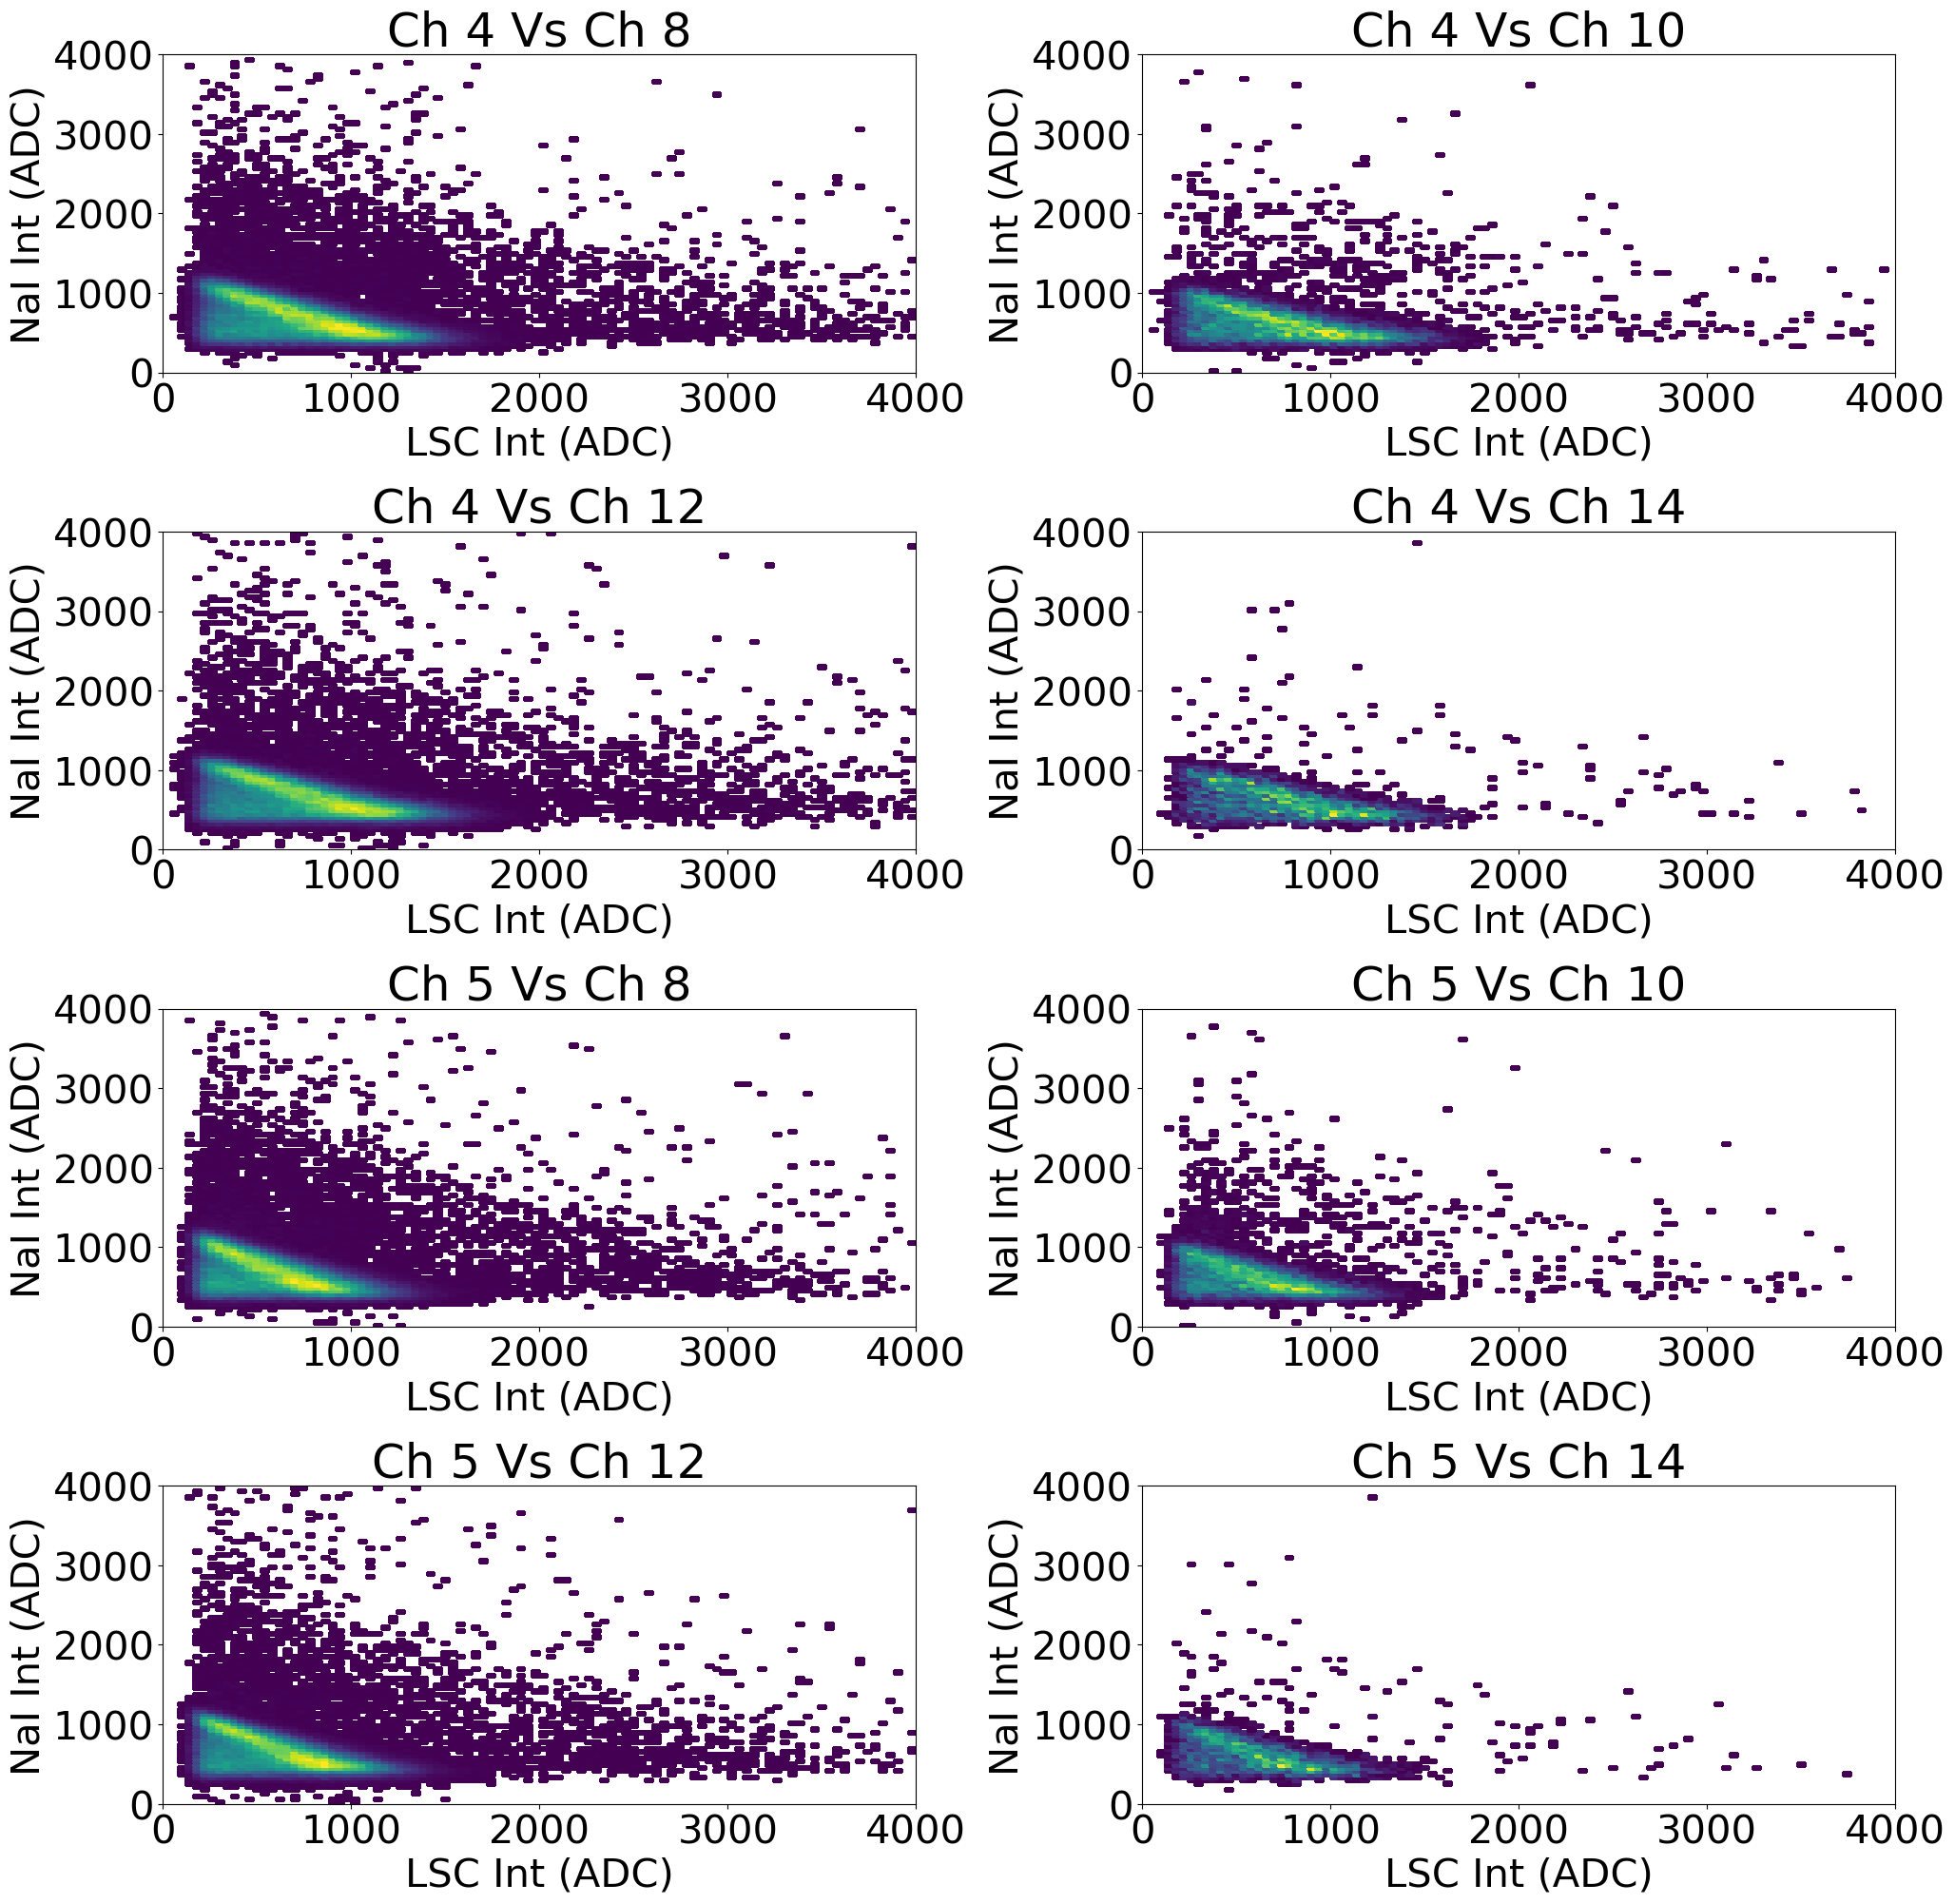

Plotting Summed Channel data from channels: [4, 8]
$\chi$^2 = 1377345.59
dof = 95.0
$chi$^2 / ndof = 14498.374626350334
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.377e+06 (χ²/ndof = 14498.4)│              Nfcn = 367              │
│ EDM = nan (Goal: 0.0002)         │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   ABOVE EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│           Hesse FAILED           │       Covariance NOT pos. def.       │
└──────────────────────────────────┴──────

/tmp/ipykernel_686491/2823225521.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axsFlat[ind].legend(loc = 'best')


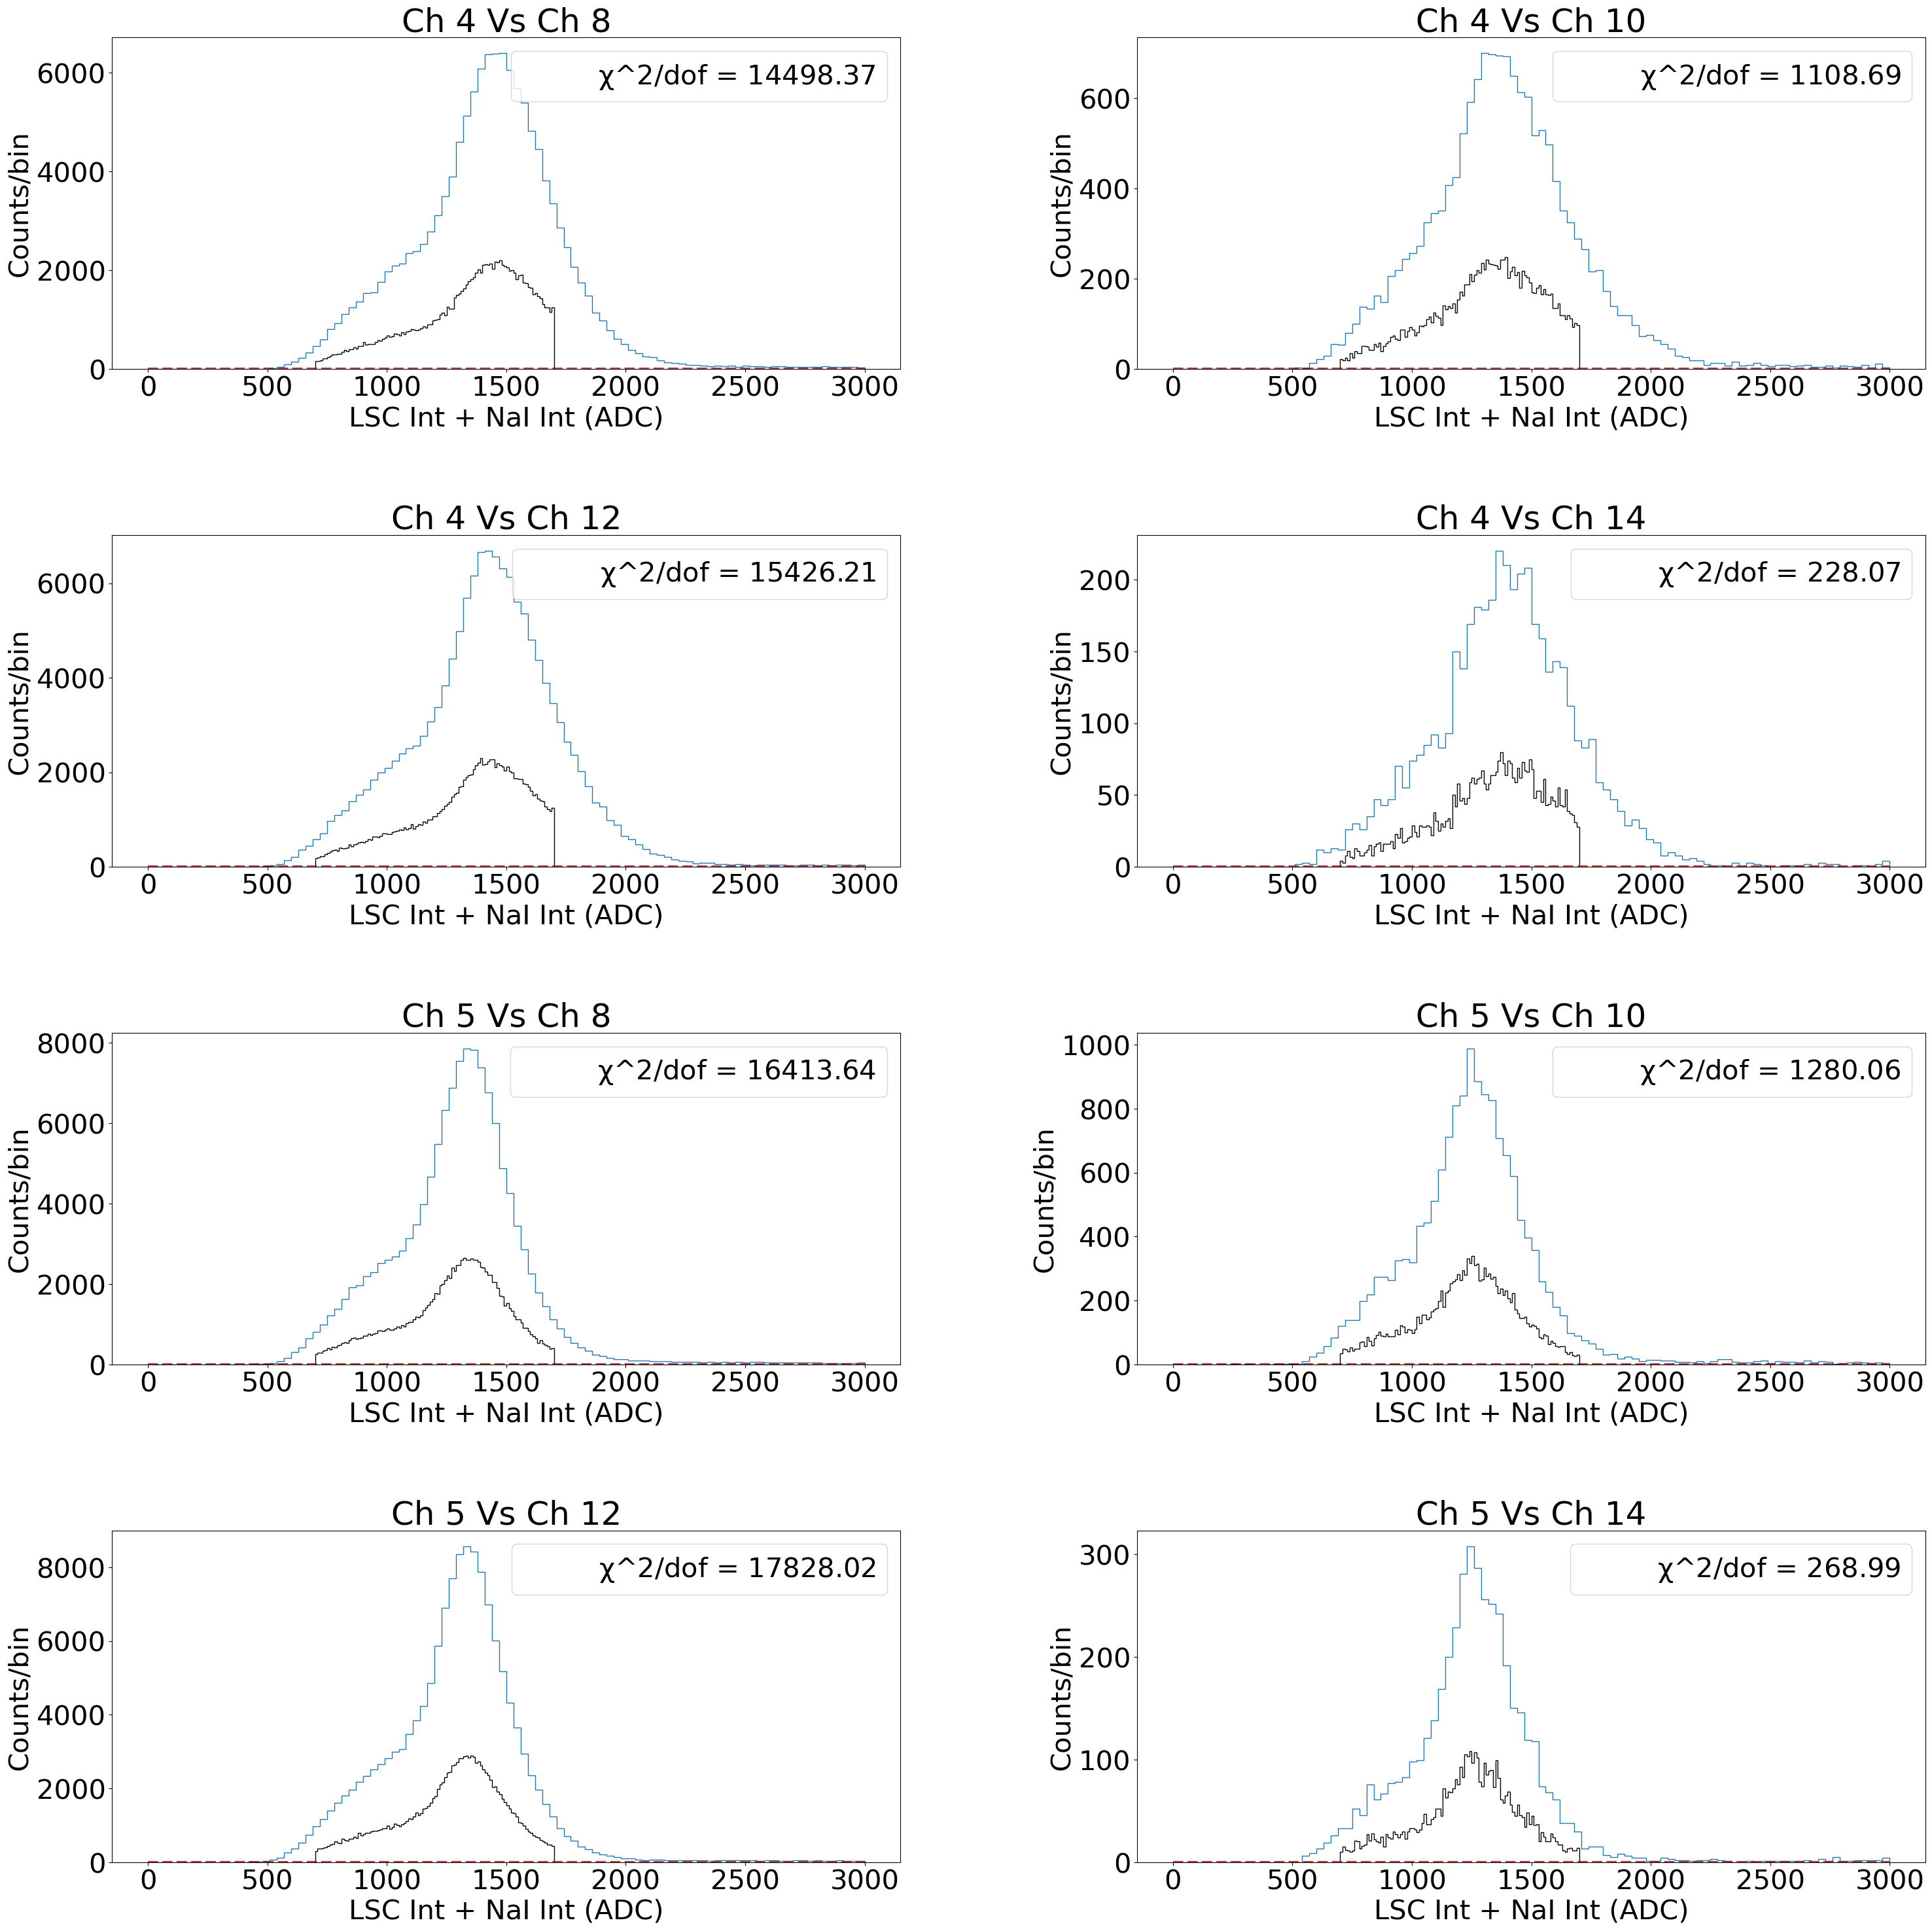

In [26]:

fig,ax = plt.subplots(4,2,figsize = (20,20))
plt.tight_layout()
plt.subplots_adjust(left = 0.05, bottom = 0.05,hspace = 0.5,wspace = 0.3)

axsFlat = ax.flatten()
for i,hist in enumerate(histogramData):
    chPairs = f'Ch {hist.Channels[0]} Vs Ch {hist.Channels[1]}'
    print(f'Plotting Histogram from channels: {hist.Channels}')
    
    hist.plot2DHist(axsFlat,savefilepath,False,i,chPairs)
plt.show()
    
    

fitData = True
fig,ax = plt.subplots(4,2,figsize = (30,30))
plt.tight_layout()
plt.subplots_adjust(left = 0.05, bottom = 0.05,hspace = 0.5,wspace = 0.3)

axsFlat = ax.flatten()
for i,hist in enumerate(histogramData):
    chPairs = f'Ch {hist.Channels[0]} Vs Ch {hist.Channels[1]}'
    print(f"Plotting Summed Channel data from channels: {hist.Channels}")
    hist.plotSummed1DHist(axsFlat,savefilepath,False,i,chPairs,fitData,plotRange)
    
plt.show()

In [48]:
cutEndPoints = [[0,0], #[x coords, y coords]
                    [0,4000],
                    [50,4000],
                    [50,1200],
                    [2000,50],
                    [4000,50],
                    [4000,0],
                    [0,0]]


cutEndPointsRotated = [[point[0]-point[1],point[0]+point[1]] for point in cutEndPoints]
print(cutEndPointsRotated)

[[0, 0], [-4000, 4000], [-3950, 4050], [-1150, 1250], [1950, 2050], [3950, 4050], [4000, 4000], [0, 0]]
